In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

Aviso: Pasta ignorada ou não encontrada: 
Processando n - geometry...
Processando n - geometry + intensity...
Processando 4n - geometry...
Processando 4n - geometry + intensity...
Processando 8n - geometry...
Processando 8n - geometry + intensity...
Processando 12n - geometry...
Processando 12n - geometry + intensity...


/tmp/ipykernel_2618/2081335464.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Experiment', y='Valor', data=df_final, order=order, palette='viridis', width=0.4)


Plotando X para n - geometry em x=1 com valor=0.86
Plotando X para n - geometry + intensity em x=2 com valor=0.85
Plotando X para 4n - geometry em x=3 com valor=0.85
Plotando X para 4n - geometry + intensity em x=4 com valor=0.86
Plotando X para 8n - geometry em x=5 com valor=0.87
Plotando X para 8n - geometry + intensity em x=6 com valor=0.89
Plotando X para 12n - geometry em x=7 com valor=0.71
Plotando X para 12n - geometry + intensity em x=8 com valor=0.85


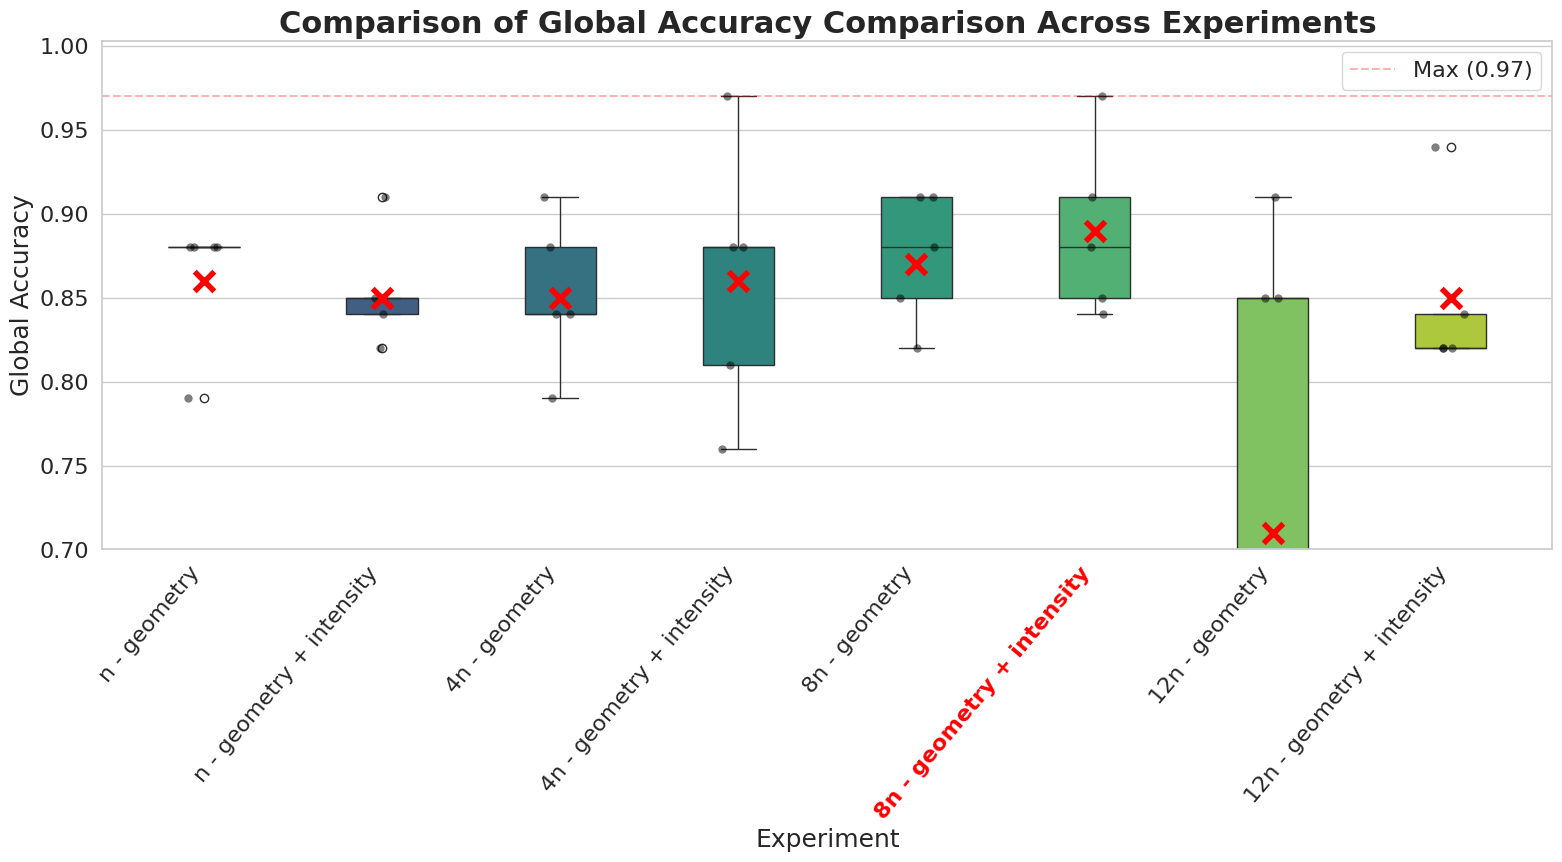

In [39]:
import re

def extract_metric_from_txt(file_path, target_row='accuracy', target_column='f1-score'):
    if not os.path.exists(file_path):
        return None

    with open(file_path, 'r') as f:
        content = f.read()

    col_index = {'precision': 0, 'recall': 1, 'f1-score': 2}

    if target_row == 'accuracy':
        # Ex: "    accuracy                           0.85       200"
        match = re.search(r'^\s*accuracy\s+([\d.]+)\s+\d+\s*$', content, re.MULTILINE)
        return float(match.group(1)) if match else None

    # Ex: "   macro avg       0.85      0.85      0.85       200"
    #     "0"        0.85      0.85      0.85       100"
    pattern = rf'^\s*{re.escape(target_row)}\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+\d+\s*$'
    match = re.search(pattern, content, re.MULTILINE | re.IGNORECASE)
    if not match:
        return None

    idx = col_index.get(target_column)
    if idx is None:
        return None
    return float(match.group(idx + 1))

def generate_experiment_boxplot(experiment_paths, target_row='accuracy', target_column='f1-score'):
    """
    Gera boxplots lendo dados de arquivos .txt de cada fold.
    """
    data_list = []

    for exp_name, base_path in experiment_paths.items():
        if not base_path or not os.path.exists(base_path):
            print(f"Aviso: Pasta ignorada ou não encontrada: {base_path}")
            continue
            
        print(f"Processando {exp_name}...")
        
        fold_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d)) and d.startswith('fase2_fold')]
        
        for fold in fold_dirs:
            fold_path = os.path.join(base_path, fold)
            txt_files = [f for f in os.listdir(fold_path) if f.endswith('.txt') and 'report' in f]
            
            if txt_files:
                report_path = os.path.join(fold_path, txt_files[0])
                val = extract_metric_from_txt(report_path, target_row, target_column)
                
                if val is not None:
                    data_list.append({
                        'Experiment': exp_name,
                        'Valor': val,
                        'Fold': fold
                    })

    df_final = pd.DataFrame(data_list)

    if df_final.empty:
        print("Nenhum dado extraído. Verifique os caminhos e o conteúdo dos arquivos .txt.")
        return

    # font_scale aumenta TUDO proporcionalmente (títulos, eixos, ticks, legenda)
    sns.set_theme(style="whitegrid", font_scale=1.6)
    plt.figure(figsize=(16, 9))
    
    order = list(experiment_paths.keys())
    
    ax = sns.boxplot(x='Experiment', y='Valor', data=df_final, order=order, palette='viridis', width=0.4)
    sns.stripplot(x='Experiment', y='Valor', data=df_final, order=order, color='black', alpha=0.5, size=6, jitter=True)
    ax.set_ylim(bottom=0.7)

    # Inserção do X vermelho nas acurácias agregadas
    for i, exp_name in enumerate(order):
        base_path = experiment_paths.get(exp_name)
        if base_path and os.path.exists(base_path):
            parent_path = os.path.dirname(base_path.rstrip('/'))
            cv_report_path = os.path.join(parent_path, 'FINAL_CV_REPORT_classification_report.txt')
            if os.path.exists(cv_report_path):
                val_agg = extract_metric_from_txt(cv_report_path, target_row, target_column)
                if val_agg is not None:
                    print(f"Plotando X para {exp_name} em x={i} com valor={val_agg}")
                    ax.scatter(i, val_agg, marker='x', color='red', s=200, zorder=10, linewidth=4)
                else:
                    print(f"Não foi possível extrair valor de {cv_report_path}")

    highlight_exp = '8n - geometry + intensity'
    for label in ax.get_xticklabels():
        if label.get_text() == highlight_exp:
            label.set_color('red')
            label.set_fontweight('bold')

    for patch in ax.artists:
        patch.set_facecolor('lightgray')

    max_global = df_final['Valor'].max()
    plt.axhline(max_global, color='red', linestyle='--', alpha=0.3, label=f'Max ({max_global:.2f})')

    metric_label = f"{target_column} ({target_row})" if target_row != 'accuracy' else "Global Accuracy"
    plt.title(f'Comparison of {metric_label} Comparison Across Experiments', fontsize=22, fontweight='bold')
    plt.xlabel('Experiment', fontsize=18)
    plt.ylabel(metric_label, fontsize=18)
    plt.xticks(rotation=50, ha='right', fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16)
    
    plt.tight_layout()
    plt.savefig('boxplot_metrics_from_txt.png', dpi=150)
    plt.show()

caminhos_experimentos = {
    'OASIS -> OASIS': '',
    'n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_2/post_trained',
    'n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_1/post_trained',
    '4n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_3/post_trained',
    '4n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_4/post_trained',
    '8n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_1/post_trained',
    '8n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_2/post_trained',
    '12n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_6/post_trained',
    '12n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_3/post_trained'
}

generate_experiment_boxplot(caminhos_experimentos)

In [25]:
import os

report_path = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_1/FINAL_CV_REPORT_classification_report.txt"

print("Existe?", os.path.exists(report_path))

with open(report_path, 'r') as f:
    lines = f.readlines()

print(f"Total de linhas: {len(lines)}")
print("=" * 60)
for i, line in enumerate(lines):
    parts = line.split()
    print(f"[{i}] repr(line) = {repr(line)}")
    print(f"     parts = {parts}")
print("=" * 60)

Existe? True
Total de linhas: 8
[0] repr(line) = '              precision    recall  f1-score   support\n'
     parts = ['precision', 'recall', 'f1-score', 'support']
[1] repr(line) = '\n'
     parts = []
[2] repr(line) = '           0       0.91      0.93      0.92       135\n'
     parts = ['0', '0.91', '0.93', '0.92', '135']
[3] repr(line) = '           1       0.64      0.57      0.60        28\n'
     parts = ['1', '0.64', '0.57', '0.60', '28']
[4] repr(line) = '\n'
     parts = []
[5] repr(line) = '    accuracy                           0.87       163\n'
     parts = ['accuracy', '0.87', '163']
[6] repr(line) = '   macro avg       0.78      0.75      0.76       163\n'
     parts = ['macro', 'avg', '0.78', '0.75', '0.76', '163']
[7] repr(line) = 'weighted avg       0.87      0.87      0.87       163\n'
     parts = ['weighted', 'avg', '0.87', '0.87', '0.87', '163']


In [ ]:
import os
import re
import pandas as pd


def parse_full_classification_report(file_path):
    """
    Lê um classification_report.txt inteiro e extrai TODAS as métricas
    disponíveis: precision/recall/f1-score para cada classe e para
    macro avg / weighted avg, além da accuracy.

    Retorna um dicionário no formato:
    {
        'accuracy': 0.87,
        '0_precision': 0.91, '0_recall': 0.93, '0_f1-score': 0.92,
        '1_precision': 0.64, '1_recall': 0.57, '1_f1-score': 0.60,
        'macro avg_precision': 0.78, ...
        'weighted avg_precision': 0.87, ...
    }
    """
    if not os.path.exists(file_path):
        return None

    with open(file_path, 'r') as f:
        content = f.read()

    metrics = {}

    # Accuracy: linha com só 1 valor + support
    match_acc = re.search(r'^\s*accuracy\s+([\d.]+)\s+\d+\s*$', content, re.MULTILINE)
    if match_acc:
        metrics['accuracy'] = float(match_acc.group(1))

    # Linhas de classe (ex: "0", "1", "2"...) e linhas de médias (macro avg, weighted avg)
    # Padrão genérico: <nome com espaços possíveis>  precision  recall  f1-score  support
    pattern = re.compile(
        r'^\s*([a-zA-Z0-9_\- ]+?)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+\d+\s*$',
        re.MULTILINE
    )
    for match in pattern.finditer(content):
        row_name = match.group(1).strip().lower()
        if row_name == 'accuracy':
            continue  # já tratado acima
        precision, recall, f1 = match.group(2), match.group(3), match.group(4)
        metrics[f'{row_name}_precision'] = float(precision)
        metrics[f'{row_name}_recall'] = float(recall)
        metrics[f'{row_name}_f1-score'] = float(f1)

    return metrics if metrics else None


def collect_fold_metrics(experiment_paths):
    """
    Percorre cada experimento, entra em cada fold, extrai todas as métricas
    e retorna um DataFrame no formato longo:
    Experiment | Fold | Metric | Valor
    """
    rows = []

    for exp_name, base_path in experiment_paths.items():
        if not base_path or not os.path.exists(base_path):
            print(f"Aviso: Pasta ignorada ou não encontrada para '{exp_name}': {base_path}")
            continue

        print(f"Processando {exp_name}...")

        fold_dirs = sorted([
            d for d in os.listdir(base_path)
            if os.path.isdir(os.path.join(base_path, d)) and d.startswith('fase2_fold')
        ])

        if not fold_dirs:
            print(f"  Nenhum fold encontrado em {base_path}")
            continue

        for fold in fold_dirs:
            fold_path = os.path.join(base_path, fold)
            txt_files = [
                f for f in os.listdir(fold_path)
                if f.endswith('.txt') and 'report' in f.lower()
            ]

            if not txt_files:
                print(f"  Aviso: nenhum .txt de report em {fold_path}")
                continue

            report_path = os.path.join(fold_path, txt_files[0])
            metrics = parse_full_classification_report(report_path)

            if metrics is None:
                print(f"  Aviso: não foi possível extrair métricas de {report_path}")
                continue

            for metric_name, value in metrics.items():
                rows.append({
                    'Experiment': exp_name,
                    'Fold': fold,
                    'Metric': metric_name,
                    'Valor': value
                })

    return pd.DataFrame(rows)


def summarize_metrics(df_long):
    """
    Recebe o DataFrame no formato longo (Experiment | Fold | Metric | Valor)
    e retorna a média e o desvio padrão de cada métrica por experimento.
    """
    summary = (
        df_long
        .groupby(['Experiment', 'Metric'])['Valor']
        .agg(mean='mean', std='std', n='count')
        .reset_index()
    )
    return summary


# ==========================================
# EXEMPLO DE USO
# ==========================================
# caminhos_experimentos = {
#     'n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_2/post_trained',
#     'n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_1/post_trained',
#     '4n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_3/post_trained',
#     '4n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/experimentos_oasis_augment/test_experimentos_4/post_trained',
#     '8n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_1/post_trained',
#     '8n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_2/post_trained',
#     '12n - geometry': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_6/post_trained',
#     '12n - geometry + intensity': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/SBCAS_2026/dgx_8n/test_experimentos_3/post_trained'
# }

caminhos_experimentos {
    
}

df_long = collect_fold_metrics(caminhos_experimentos)
resumo = summarize_metrics(df_long)

# Mostra tudo
pd.set_option('display.max_rows', None)
print(resumo)

# Salva em CSV pra você abrir no Excel/Sheets
resumo.to_csv('resumo_metricas_por_experimento.csv', index=False)

# Se quiser ver só a acurácia média/desvio de cada experimento:
print("\n=== ACURÁCIA (média ± desvio padrão) ===")
acc_summary = resumo[resumo['Metric'] == 'accuracy']
print(acc_summary[['Experiment', 'mean', 'std']])

Processando n - geometry...
Processando n - geometry + intensity...
Processando 4n - geometry...
Processando 4n - geometry + intensity...
Processando 8n - geometry...
Processando 8n - geometry + intensity...
Processando 12n - geometry...
Processando 12n - geometry + intensity...
                     Experiment                  Metric   mean       std  n
0                12n - geometry              0_f1-score  0.754  0.264632  5
1                12n - geometry             0_precision  0.978  0.031937  5
2                12n - geometry                0_recall  0.674  0.307620  5
3                12n - geometry              1_f1-score  0.574  0.185149  5
4                12n - geometry             1_precision  0.478  0.241806  5
5                12n - geometry                1_recall  0.900  0.148155  5
6                12n - geometry                accuracy  0.710  0.247790  5
7                12n - geometry      macro avg_f1-score  0.662  0.220952  5
8                12n - geometry     